# Demixed PCA of maintenance period trajectories

Notebook created: 7/1/26
Studying multiload models

Modeled after maintenance_traj_v2, but using demixed PCA (dPCA) instead of PCA.

dPCA (Brendel et al. 2011, Kobak et al. 2016) decomposes neural activity into components  
that are selective for specific task parameters (load, stimulus, time) vs. mixtures of them.

Two analyses:
1. **Load x Time dPCA**: condition-averaged over stimuli — which components are load-tuned vs. time-evolving?
2. **Stimulus x Time dPCA (load 1)**: condition-averaged over stimulus identity — which components are stimulus-tuned?

In [1]:
%matplotlib inline
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis')
import generate_rate_data_multiload as grdm
import os
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld
import rate_neuron_utils as rn

from dPCA import dPCA

2026-07-02 19:09:05.582723: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-02 19:09:05.590504: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-02 19:09:05.599294: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-02 19:09:05.601946: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-02 19:09:05.609142: I tensorflow/core/platform/cpu_feature_guar

In [2]:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_041152.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_180002.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_233744.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_023239.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_043128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063647.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

condn_phrase = 'delay'
condn_num = 150

In [3]:
settings = {
    "T": 450,
    "stim_on": 50,
    "stim_dur": 25,
    "delay": 150,
    "DeltaT": 1,
    "taus": 20,
    "fs": 200,
    "task": "sternberg",
    "load": 1,
}
N_STIM = 4  # stimulus identities (0-3)

## Helper: load and preprocess maintenance-period rates

In [4]:
def load_maintenance_rates(model_name):
    """Returns rates_maint (trials x neurons x time), trial_labels_corr."""
    other_labels = 'precomputed_balanced123'
    _, rates_data = ld.load_neural_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels=other_labels,
        all_models_dir=all_models_dir, load_LFP=False
    )
    trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels=other_labels,
        all_models_dir=all_models_dir
    )

    correct_idxs = np.where(trial_perfs == 1)[0]
    rates_corr = rates_data[correct_idxs]          # trials x neurons x time
    trial_labels_corr = trial_labels[correct_idxs] # trials x labels

    n_trials, n_neurons, _ = rates_corr.shape
    rates_maint = np.zeros((n_trials, n_neurons, settings["delay"]))
    for i in range(n_trials):
        load = trial_labels_corr[i, 0]
        delay_start = int(settings["stim_on"] + settings["stim_dur"] * load)
        delay_end = delay_start + settings["delay"]
        rates_maint[i] = rates_corr[i, :, delay_start:delay_end]

    return rates_maint, trial_labels_corr

## Analysis 1: Load x Time dPCA (single model)

Condition-average over stimulus identity to get a tensor of shape **(N, n_loads, T)**,
then demix into load-tuned, time-evolving, and interaction components.

In [5]:
model_name = model_names[10]

rates_maint, trial_labels_corr = load_maintenance_rates(model_name)
n_neurons = rates_maint.shape[1]
n_time    = rates_maint.shape[2]
n_loads   = 3

load1_idxs = np.where(trial_labels_corr[:, 0] == 1)[0]
load2_idxs = np.where(trial_labels_corr[:, 0] == 2)[0]
load3_idxs = np.where(trial_labels_corr[:, 0] == 3)[0]

### balance stims

In [6]:
import numpy as np
N_STIM = 4  # 0-3, same identity space in all loads

# ---------- Step 1: figure out per-condition trial cap for each load ----------

# load1: stim1s = shown stimulus id per trial
stim1s = trial_labels_corr[load1_idxs, 2]
cap1_per_id = [np.sum(stim1s == i) for i in range(N_STIM)]
cap1 = min(cap1_per_id)

# load2: stim2s = pair of stimulus ids per trial; pool trials containing each id
stim2s = np.sort(trial_labels_corr[load2_idxs, 2:4], axis=1)
cap2_per_id = [np.sum(np.any(stim2s == i, axis=1)) for i in range(N_STIM)]
cap2 = min(cap2_per_id)

# load3: stim3s = triplet of shown stimulus ids per trial; pool trials containing each id
stim3s = trial_labels_corr[load3_idxs, 2:5]
cap3_per_id = [np.sum(np.any(stim3s == i, axis=1)) for i in range(N_STIM)]
cap3 = min(cap3_per_id)

n_trials = min(cap1, cap2, cap3)
print(f"caps: load1={cap1}, load2={cap2}, load3={cap3} -> using n_trials={n_trials}")

# ---------- Step 2: sample n_trials per identity, per load ----------

def sample_direct(idxs, ids, n_per_identity, seed=None):
    """ids: per-trial stimulus identity (0..N_STIM-1), same length as idxs"""
    rng = np.random.default_rng(seed)
    out = {}
    for stim_id in range(N_STIM):
        cond_idxs = idxs[ids == stim_id]
        out[stim_id] = rng.choice(cond_idxs, size=n_per_identity, replace=False)
    return out

def sample_from_membership(idxs, group_ids, n_per_identity, seed=None):
    """group_ids: (n_trials, k) array of shown stimulus ids per trial (k=2 for load2, k=3 for load3);
    pool trials containing each identity"""
    rng = np.random.default_rng(seed)
    out = {}
    for stim_id in range(N_STIM):
        cond_idxs = idxs[np.any(group_ids == stim_id, axis=1)]
        out[stim_id] = rng.choice(cond_idxs, size=n_per_identity, replace=False)
    return out

sampled1 = sample_direct(load1_idxs, stim1s, n_trials)
sampled2 = sample_from_membership(load2_idxs, stim2s, n_trials)
sampled3 = sample_from_membership(load3_idxs, stim3s, n_trials)

caps: load1=35, load2=77, load3=189 -> using n_trials=35


In [7]:
# ---------- Step 3: build trialR ----------

n_loads = 3
trialR = np.zeros((n_trials, n_neurons, n_loads, N_STIM, n_time))  # no NaNs needed

def get_trial_data(idx):
    return rates_maint[idx]   # (n_neurons, n_time) — adapt to your data storage

def fill(trialR, load_col, sampled_dict):
    for stim_id, trial_idxs in sampled_dict.items():
        for t, idx in enumerate(trial_idxs):
            trialR[t, :, load_col, stim_id, :] = get_trial_data(idx)

fill(trialR, 0, sampled1)
fill(trialR, 1, sampled2)
fill(trialR, 2, sampled3)

In [8]:
# 1. every (load, stim) cell should be fully populated, no leftover zeros from init
assert not np.any(np.all(trialR == 0, axis=(0, 1)))  # per load/stim slice not all-zero (weak check, but catches misses)

# 2. counts match expectation
for load_col, sampled in enumerate([sampled1, sampled2, sampled3]):
    for stim_id, idxs_ in sampled.items():
        assert len(idxs_) == n_trials

# 3. (load2-specific) verify each sampled trial actually contains the claimed stim_id
for stim_id, idxs_ in sampled2.items():
    rows = np.array([np.any(stim2s[load2_idxs == i]) for i in idxs_])  # sanity, adjust indexing to your data layout

In [9]:
# Mean over repetitions
R = trialR.mean(axis=0)

# Mean-center neurons (same as before)
R -= R.mean(axis=(1, 2, 3), keepdims=True)   # mean over load, stim, time — per neuron

In [10]:
dpca = dPCA.dPCA(labels='lst', regularizer='auto')
dpca.protect = ['t']

Z = dpca.fit_transform(R, trialR)

You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.003388200529767837
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please                    set opt_regularizer_flag to True.


Explained variance by marginalization:
  l: [0.0212 0.0001 0.     0.     0.     0.     0.     0.     0.     0.    ]
  s: [0.1201 0.0917 0.042  0.     0.     0.     0.     0.     0.     0.    ]
  t: [0.1704 0.0031 0.     0.     0.     0.     0.     0.     0.     0.    ]
  ls: [0.0361 0.0253 0.0237 0.0001 0.     0.     0.     0.     0.     0.    ]
  lt: [0.0016 0.     0.     0.     0.     0.     0.     0.     0.     0.    ]
  st: [0.0031 0.0018 0.0006 0.     0.     0.     0.     0.     0.     0.    ]
  lst: [0.0007 0.0005 0.0003 0.     0.     0.     0.     0.     0.     0.    ]


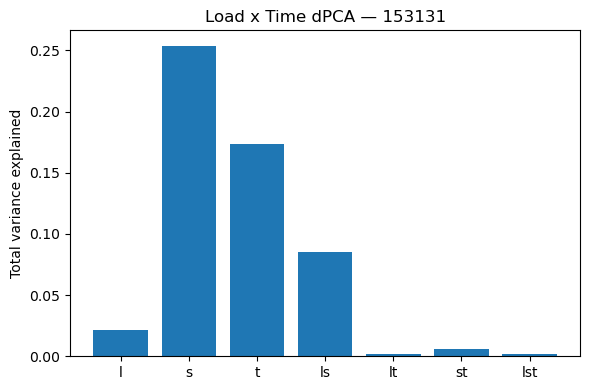

In [11]:
# Variance explained per marginalization
varexp = dpca.explained_variance_ratio_
print('Explained variance by marginalization:')
for key, val in varexp.items():
    print(f'  {key}: {np.round(val, 4)}')

# Bar chart of total variance per marginalization
fig, ax = plt.subplots(figsize=(6, 4))
keys = list(varexp.keys())
totals = [np.array(varexp[k]).sum() for k in keys]
ax.bar(keys, totals)
ax.set_ylabel('Total variance explained')
ax.set_title(f'Load x Time dPCA — {model_name[-6:]}')
plt.tight_layout()
plt.show()

A few things jump out:
Stimulus identity is the dominant signal (s = 0.279), and it's genuinely load-invariant for the most part. Most of the stimulus-related variance sits in the pure s marginalization rather than ls — meaning a large chunk of how neurons encode "which stimulus" doesn't change much with load. That's actually a useful finding on its own: there's a stable, load-general stimulus code.
Pure load effects are almost negligible (l = 0.019). This is the important one for your question. If neurons were simply scaling their firing rate up/down as a function of load (a simple gain/baseline shift, independent of what's being remembered), you'd expect l to be large. It's not — barely anything is explained by load alone.
But load×stimulus interaction is meaningfully sized (ls = 0.076) — about 4x larger than pure load. This is the more interesting story: load doesn't act as a blanket gain change, it specifically reshapes how stimuli are represented. The stimulus code itself shifts, rotates, or changes in some load-dependent way, rather than the whole population just firing more/less.
Time dominates overall (t = 0.174), and lt is tiny (0.002) — so temporal dynamics (e.g., ramping, decay) are strong, but largely load-invariant, i.e. the shape of the temporal trajectory doesn't change much with load.
Bottom line for your question: the data are consistent with the idea that higher memory load doesn't recruit a separate "load" signal so much as it modifies the geometry of the stimulus code itself (ls > l by a wide margin). If you had to describe the mechanism in one line: "load reshapes how stimuli are encoded, rather than uniformly scaling activity."

#### analysis

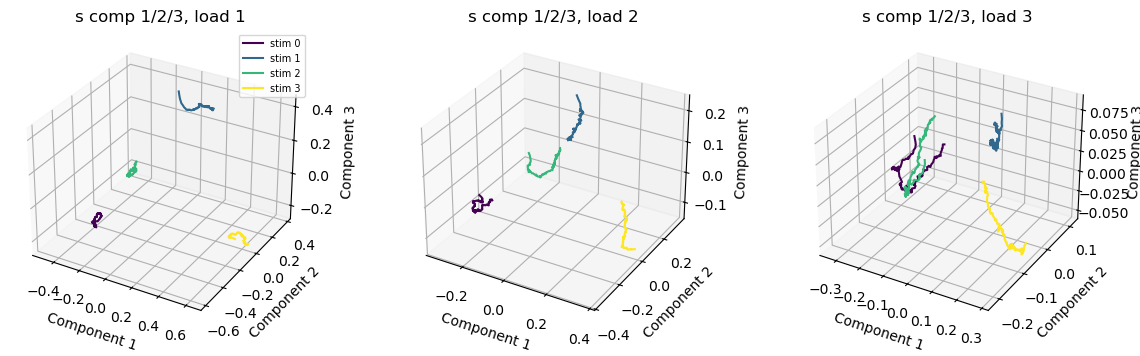

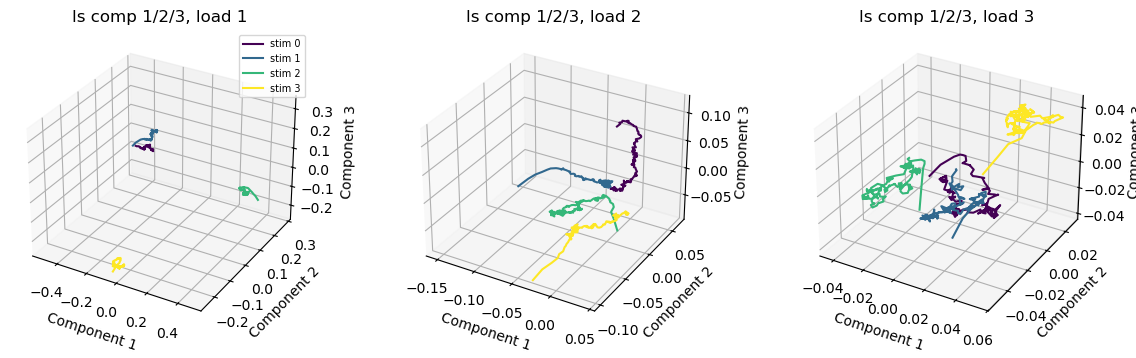

In [12]:
time = np.arange(n_time)  
colors = plt.cm.viridis(np.linspace(0, 1, N_STIM))

# 3d plots
for marg in ['s', 'ls']:
    fig, axs = plt.subplots(1, n_loads, figsize=(4*n_loads, 3.5),  subplot_kw=dict(projection='3d'))
    for load in range(n_loads):
        for stim in range(N_STIM):
            axs[load].plot(Z[marg][0, load, stim, :], Z[marg][1, load, stim, :], Z[marg][2, load, stim, :],
                            color=colors[stim], label=f'stim {stim}')
        axs[load].set_title(f'{marg} comp 1/2/3, load {load+1}')
        axs[load].set_xlabel('Component 1')
        axs[load].set_ylabel('Component 2')
        axs[load].set_zlabel('Component 3')
    axs[0].legend(fontsize=7)
    plt.tight_layout()
    plt.show()

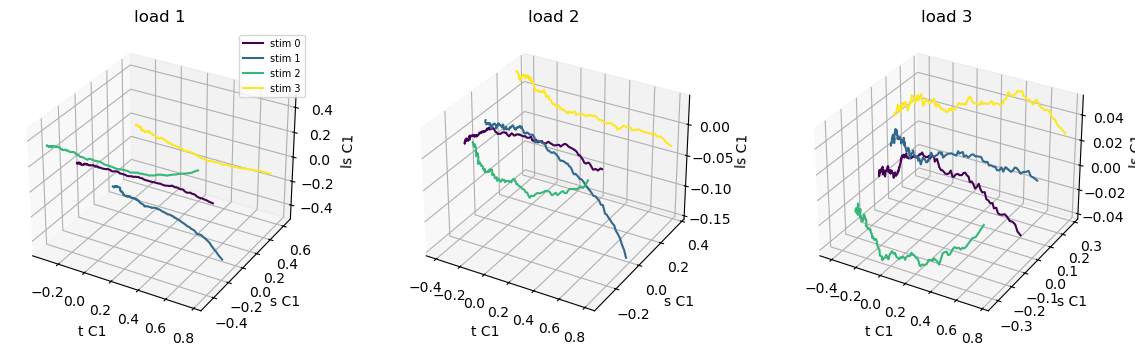

In [16]:
marg1 = 't'
marg2 = 's'
marg3 = 'ls'

fig, axs = plt.subplots(1, n_loads, figsize=(4*n_loads, 3.5),  subplot_kw=dict(projection='3d'))
for load in range(n_loads):
    for stim in range(N_STIM):
        axs[load].plot(Z[marg1][0, load, stim, :], Z[marg2][0, load, stim, :], Z[marg3][0, load, stim, :],
                        color=colors[stim], label=f'stim {stim}')
    axs[load].set_title(f'load {load+1}')
    axs[load].set_xlabel(f'{marg1} C1')
    axs[load].set_ylabel(f'{marg2} C1')
    axs[load].set_zlabel(f'{marg3} C1')
axs[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

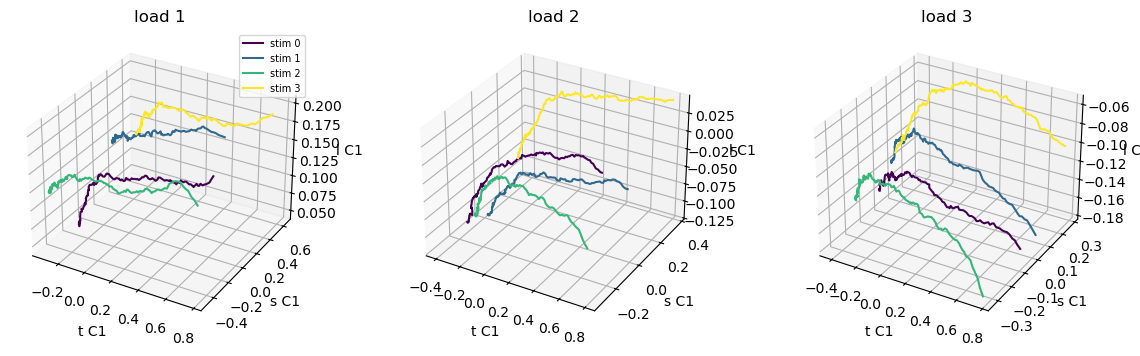

In [17]:
marg1 = 't'
marg2 = 's'
marg3 = 'l'

fig, axs = plt.subplots(1, n_loads, figsize=(4*n_loads, 3.5),  subplot_kw=dict(projection='3d'))
for load in range(n_loads):
    for stim in range(N_STIM):
        axs[load].plot(Z[marg1][0, load, stim, :], Z[marg2][0, load, stim, :], Z[marg3][0, load, stim, :],
                        color=colors[stim], label=f'stim {stim}')
    axs[load].set_title(f'load {load+1}')
    axs[load].set_xlabel(f'{marg1} C1')
    axs[load].set_ylabel(f'{marg2} C1')
    axs[load].set_zlabel(f'{marg3} C1')
axs[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

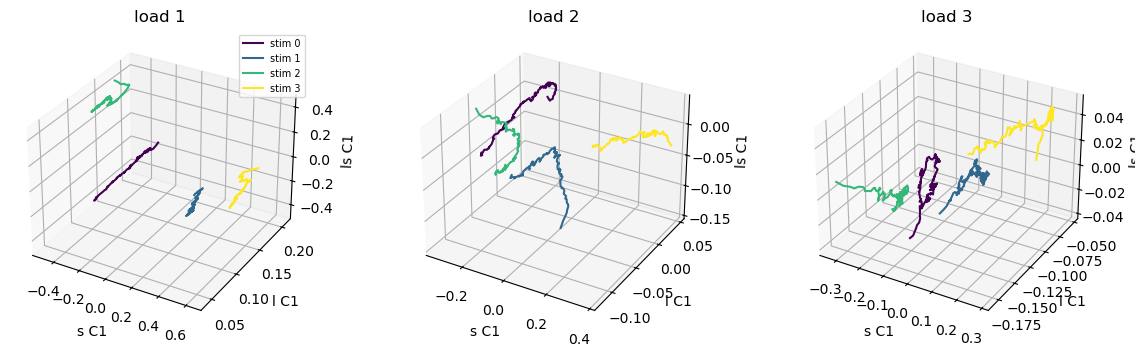

In [15]:
marg1 = 's'
marg2 = 'l'
marg3 = 'ls'

fig, axs = plt.subplots(1, n_loads, figsize=(4*n_loads, 3.5),  subplot_kw=dict(projection='3d'))
for load in range(n_loads):
    for stim in range(N_STIM):
        axs[load].plot(Z[marg1][0, load, stim, :], Z[marg2][0, load, stim, :], Z[marg3][0, load, stim, :],
                        color=colors[stim], label=f'stim {stim}')
    axs[load].set_title(f'load {load+1}')
    axs[load].set_xlabel(f'{marg1} C1')
    axs[load].set_ylabel(f'{marg2} C1')
    axs[load].set_zlabel(f'{marg3} C1')
axs[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
from itertools import combinations

# def stim_axis_per_load(R, load, dpca_marg_dim, n_components=1):
#     """
#     R: (n_neurons, n_loads, n_stim, n_time) trial-averaged, centered
#     Returns the mean-difference vector for each stim pair at this load,
#     averaged over a time window, as a proxy 'stimulus axis' in neuron space.
#     """
#     # average over a chosen time window (e.g. delay period) — adjust indices
#     delay_window = slice(t_start, t_end)
#     R_load = R[:, load, :, delay_window].mean(axis=-1)  # (n_neurons, n_stim)
#     return R_load  # each column is that stim's population mean vector

def stim_axis_per_load(R, load, dpca_marg_dim, n_components=1):
    """
    R: (n_neurons, n_loads, n_stim, n_time) trial-averaged, centered
    Returns the mean-difference vector for each stim pair at this load,
    averaged over a time window, as a proxy 'stimulus axis' in neuron space.
    """
    # average over a chosen time window (e.g. delay period) — adjust indices
    R_load = R[:, load, :, :].mean(axis=-1)  # (n_neurons, n_stim)
    return R_load  # each column is that stim's population mean vector

def pairwise_angles(R_load):
    """cosine angle between each pair of stimulus mean vectors, after centering across stims"""
    R_centered = R_load - R_load.mean(axis=1, keepdims=True)  # remove grand mean across stim
    n_stim = R_centered.shape[1]
    angles = np.full((n_stim, n_stim), np.nan)
    for i, j in combinations(range(n_stim), 2):
        v1, v2 = R_centered[:, i], R_centered[:, j]
        cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        angles[i, j] = angles[j, i] = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))
    return angles

# compute per-load stimulus vectors
stim_vecs = {load: stim_axis_per_load(R, load, 's') for load in range(n_loads)}

# THE KEY TEST: angle between load1's stim-i axis and load3's stim-i axis
def cross_load_axis_angle(vecs_a, vecs_b, stim_id, n_stim):
    va = vecs_a[:, stim_id] - vecs_a.mean(axis=1)
    vb = vecs_b[:, stim_id] - vecs_b.mean(axis=1)
    cos_theta = np.dot(va, vb) / (np.linalg.norm(va) * np.linalg.norm(vb))
    return np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))

for stim in range(N_STIM):
    angle_1v3 = cross_load_axis_angle(stim_vecs[0], stim_vecs[2], stim, N_STIM)
    print(f"stim {stim}: load1 vs load3 axis angle = {angle_1v3:.1f} deg")

stim 0: load1 vs load3 axis angle = 33.6 deg
stim 1: load1 vs load3 axis angle = 50.6 deg
stim 2: load1 vs load3 axis angle = 48.9 deg
stim 3: load1 vs load3 axis angle = 33.7 deg


In [56]:
def check_betweenness(load1_vecs, load2_pair_vec, stim_i, stim_j):
    """Is load2's representation of pair (i,j) ~ midpoint of load1's stim_i and stim_j vectors?"""
    v_i = load1_vecs[:, stim_i] - load1_vecs.mean(axis=1)
    v_j = load1_vecs[:, stim_j] - load1_vecs.mean(axis=1)
    midpoint = (v_i + v_j) / 2
    v_pair = load2_pair_vec - load2_pair_vec.mean()  # adapt indexing to your load2 storage

    cos_theta = np.dot(midpoint, v_pair) / (np.linalg.norm(midpoint) * np.linalg.norm(v_pair))
    return np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))

stim_pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
for stim_i, stim_j in stim_pairs:
    angle_1v2 = check_betweenness(stim_vecs[0], stim_vecs[1], stim_i, stim_j)
    print(f"stim ({stim_i}, {stim_j}): load1 vs load2 axis angle = {angle_1v2} deg")

stim (0, 1): load1 vs load2 axis angle = [74.33129757 82.30713919 99.81459863 99.69585377] deg
stim (0, 2): load1 vs load2 axis angle = [ 72.11662335  98.2332811   72.50556035 112.69137934] deg
stim (0, 3): load1 vs load2 axis angle = [ 69.76635204 105.34923155 109.70932889  77.61420288] deg
stim (1, 2): load1 vs load2 axis angle = [110.23364796  74.65076845  70.29067111 102.38579712] deg
stim (1, 3): load1 vs load2 axis angle = [107.88337665  81.7667189  107.49443965  67.30862066] deg
stim (2, 3): load1 vs load2 axis angle = [105.66870243  97.69286081  80.18540137  80.30414623] deg


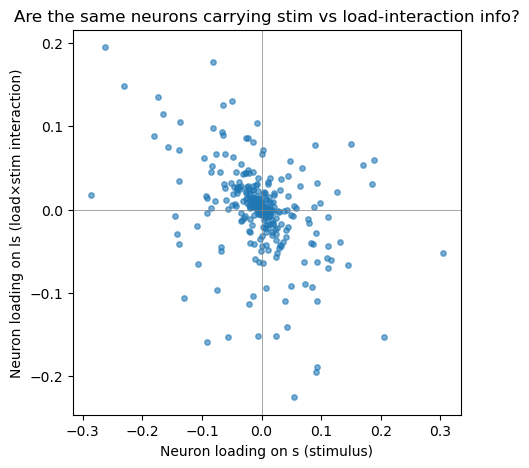

correlation between s and ls loadings: r=-0.387, p=0.0000


In [57]:
from scipy.stats import pearsonr

# dpca.D['s'] and dpca.D['ls'] are decoder matrices: (n_neurons, n_components)
loadings_s = dpca.D['s'][:, 0]   # first component
loadings_ls = dpca.D['ls'][:, 0]

plt.figure(figsize=(5, 5))
plt.scatter(loadings_s, loadings_ls, alpha=0.6, s=15)
plt.xlabel('Neuron loading on s (stimulus)')
plt.ylabel('Neuron loading on ls (load×stim interaction)')
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.title('Are the same neurons carrying stim vs load-interaction info?')
plt.show()

r, p = pearsonr(loadings_s, loadings_ls)
print(f"correlation between s and ls loadings: r={r:.3f}, p={p:.4f}")

## Analysis 1 applied across models

In [ ]:
for i, model_name in enumerate(model_names):

    rates_maint, trial_labels_corr = load_maintenance_rates(model_name)
    n_neurons = rates_maint.shape[1]
    n_time    = rates_maint.shape[2]
    n_loads   = 3

    load1_idxs = np.where(trial_labels_corr[:, 0] == 1)[0]
    load2_idxs = np.where(trial_labels_corr[:, 0] == 2)[0]
    load3_idxs = np.where(trial_labels_corr[:, 0] == 3)[0]

In [ ]:
n_trials = np.amin([len(load1_idxs), len(load2_idxs), len(load3_idxs)])
n_trials

142

### balancing stims, but including trials multiple times if stim was shown

#### load3 as left out

In [ ]:
# ------------------------------
# Build trialR for dPCA
# Dimensions:
# (repetitions, neurons, load, stimulus, time)
# ------------------------------

rng = np.random.default_rng(0)

n_stim = 4

# Load indices
load1_idxs = np.where(trial_labels_corr[:, 0] == 1)[0]
load2_idxs = np.where(trial_labels_corr[:, 0] == 2)[0]
load3_idxs = np.where(trial_labels_corr[:, 0] == 3)[0]

# Number of available repetitions for each stimulus in each load

# Load 1
load1_counts = np.array([
    np.sum(trial_labels_corr[load1_idxs, 2] == stim)
    for stim in range(n_stim)
])

# Load 2
stim_pairs = trial_labels_corr[load2_idxs, 2:4]
load2_counts = np.array([
    np.sum(np.any(stim_pairs == stim, axis=1))
    for stim in range(n_stim)
])

# Load 3
left_out = np.array([
    np.setdiff1d(np.arange(n_stim), trial)[0]
    for trial in trial_labels_corr[load3_idxs, 2:5]
])

load3_counts = np.array([
    np.sum(left_out != stim)
    for stim in range(n_stim)
])

print("Load1 counts:", load1_counts)
print("Load2 counts:", load2_counts)
print("Load3 counts:", load3_counts)

# Common number of repetitions
n_reps = min(
    load1_counts.min(),
    load2_counts.min(),
    load3_counts.min()
)

print(f"Using {n_reps} repetitions per (load, stimulus).")

# Allocate
trialR = np.empty((n_reps, n_neurons, 3, n_stim, n_time))

# ------------------------------
# Load 1
# ------------------------------
for stim in range(n_stim):

    idxs = load1_idxs[
        trial_labels_corr[load1_idxs, 2] == stim
    ]

    idxs = rng.choice(idxs, size=n_reps, replace=False)

    trialR[:, :, 0, stim, :] = rates_maint[idxs]

# ------------------------------
# Load 2
# ------------------------------
for stim in range(n_stim):

    mask = np.any(stim_pairs == stim, axis=1)
    idxs = load2_idxs[mask]

    idxs = rng.choice(idxs, size=n_reps, replace=False)

    trialR[:, :, 1, stim, :] = rates_maint[idxs]

# ------------------------------
# Load 3
# ------------------------------
for stim in range(n_stim):

    mask = left_out != stim
    idxs = load3_idxs[mask]

    idxs = rng.choice(idxs, size=n_reps, replace=False)

    trialR[:, :, 2, stim, :] = rates_maint[idxs]

# Mean over repetitions
R_old = trialR.mean(axis=0)

# Mean-center neurons (same as before)
R_old -= R_old.mean(axis=0, keepdims=True)

print("trialR shape:", trialR.shape)
print("R_old shape:", R_old.shape)

Load1 counts: [36 35 35 36]
Load2 counts: [ 81 105  77  83]
Load3 counts: [198 248 189 202]
Using 35 repetitions per (load, stimulus).
trialR shape: (35, 1000, 3, 4, 150)
R_old shape: (1000, 3, 4, 150)


In [ ]:
dpca = dPCA.dPCA(labels='lst', regularizer='auto')
dpca.protect = ['t']

Z = dpca.fit_transform(R_old, trialR)

You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.003388200529767837
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please                    set opt_regularizer_flag to True.


Explained variance by marginalization:
  l: [0.0205 0.     0.     0.     0.     0.     0.     0.     0.     0.    ]
  s: [0.1432 0.0965 0.0432 0.     0.     0.     0.     0.     0.     0.    ]
  t: [0.1699 0.0027 0.     0.     0.     0.     0.     0.     0.     0.    ]
  ls: [0.0374 0.0219 0.0166 0.     0.     0.     0.     0.     0.     0.    ]
  lt: [0.0017 0.     0.     0.     0.     0.     0.     0.     0.     0.    ]
  st: [0.0028 0.0024 0.0008 0.     0.     0.     0.     0.     0.     0.    ]
  lst: [0.0009 0.0004 0.0002 0.     0.     0.     0.     0.     0.     0.    ]


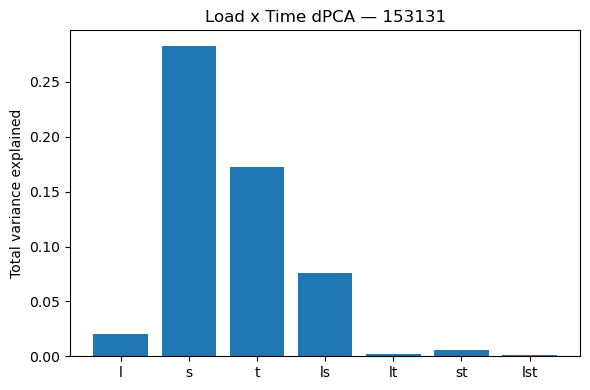

In [ ]:
# Variance explained per marginalization
varexp = dpca.explained_variance_ratio_
print('Explained variance by marginalization:')
for key, val in varexp.items():
    print(f'  {key}: {np.round(val, 4)}')

# Bar chart of total variance per marginalization
fig, ax = plt.subplots(figsize=(6, 4))
keys = list(varexp.keys())
totals = [np.array(varexp[k]).sum() for k in keys]
ax.bar(keys, totals)
ax.set_ylabel('Total variance explained')
ax.set_title(f'Load x Time dPCA — {model_name[-6:]}')
plt.tight_layout()
plt.show()

- Stimulus identity is strongly encoded across loads  
- Strong shared temporal dynamics component (eg ramping, delay-period drift, global gain changes, task epoch structure)  
- Almost no pure load axis
- Stimulus coding somewhat depends on load 

But since stimulus is present in every load-2 pair and load-3 complement, stimulus signal is by default strong

#### load3 as 3 stims

In [ ]:
# ------------------------------
# Build trialR for dPCA
# Dimensions:
# (repetitions, neurons, load, stimulus, time)
# ------------------------------

rng = np.random.default_rng(0)

n_stim = 4

# Load indices
load1_idxs = np.where(trial_labels_corr[:, 0] == 1)[0]
load2_idxs = np.where(trial_labels_corr[:, 0] == 2)[0]
load3_idxs = np.where(trial_labels_corr[:, 0] == 3)[0]

# Number of available repetitions for each stimulus in each load

# Load 1
load1_counts = np.array([
    np.sum(trial_labels_corr[load1_idxs, 2] == stim)
    for stim in range(n_stim)
])

# Load 2
stim_pairs = trial_labels_corr[load2_idxs, 2:4]
load2_counts = np.array([
    np.sum(np.any(stim_pairs == stim, axis=1))
    for stim in range(n_stim)
])

# Load 3
stim_trips = trial_labels_corr[load3_idxs, 2:5]
load3_counts = np.array([
    np.sum(np.any(stim_trips == stim, axis=1))
    for stim in range(n_stim)
])

print("Load1 counts:", load1_counts)
print("Load2 counts:", load2_counts)
print("Load3 counts:", load3_counts)

# Common number of repetitions
n_reps = min(
    load1_counts.min(),
    load2_counts.min(),
    load3_counts.min()
)

print(f"Using {n_reps} repetitions per (load, stimulus).")

# Allocate
trialR = np.empty((n_reps, n_neurons, 3, n_stim, n_time))

# ------------------------------
# Load 1
# ------------------------------
for stim in range(n_stim):

    idxs = load1_idxs[
        trial_labels_corr[load1_idxs, 2] == stim
    ]

    idxs = rng.choice(idxs, size=n_reps, replace=False)

    trialR[:, :, 0, stim, :] = rates_maint[idxs]

# ------------------------------
# Load 2
# ------------------------------
for stim in range(n_stim):

    mask = np.any(stim_pairs == stim, axis=1)
    idxs = load2_idxs[mask]

    idxs = rng.choice(idxs, size=n_reps, replace=False)

    trialR[:, :, 1, stim, :] = rates_maint[idxs]

# ------------------------------
# Load 3
# ------------------------------
for stim in range(n_stim):

    mask = np.any(stim_trips == stim, axis=1)
    idxs = load3_idxs[mask]

    idxs = rng.choice(idxs, size=n_reps, replace=False)

    trialR[:, :, 2, stim, :] = rates_maint[idxs]

# Mean over repetitions
R = trialR.mean(axis=0)

# Mean-center neurons (same as before)
R -= R.mean(axis=0, keepdims=True)

print("trialR shape:", trialR.shape)
print("R shape:", R.shape)

Load1 counts: [36 35 35 36]
Load2 counts: [ 81 105  77  83]
Load3 counts: [198 248 189 202]
Using 35 repetitions per (load, stimulus).
trialR shape: (35, 1000, 3, 4, 150)
R shape: (1000, 3, 4, 150)


In [ ]:
dpca = dPCA.dPCA(labels='lst', regularizer='auto')
dpca.protect = ['t']

Z = dpca.fit_transform(R, trialR)

You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.003388200529767837
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please                    set opt_regularizer_flag to True.


Explained variance by marginalization:
  l: [0.0205 0.     0.     0.     0.     0.     0.     0.     0.     0.    ]
  s: [0.1432 0.0965 0.0432 0.     0.     0.     0.     0.     0.     0.    ]
  t: [0.1699 0.0027 0.     0.     0.     0.     0.     0.     0.     0.    ]
  ls: [0.0374 0.0219 0.0166 0.     0.     0.     0.     0.     0.     0.    ]
  lt: [0.0017 0.     0.     0.     0.     0.     0.     0.     0.     0.    ]
  st: [0.0028 0.0024 0.0008 0.     0.     0.     0.     0.     0.     0.    ]
  lst: [0.0009 0.0004 0.0002 0.     0.     0.     0.     0.     0.     0.    ]


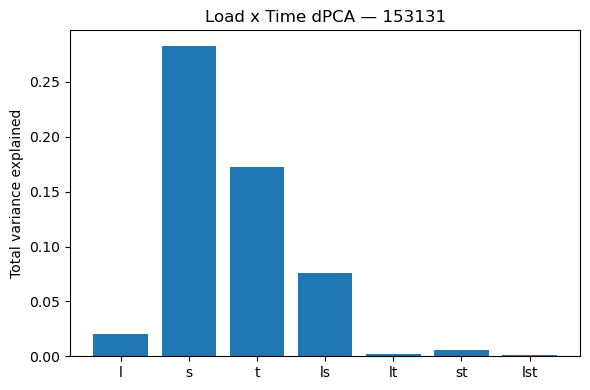

In [ ]:
# Variance explained per marginalization
varexp = dpca.explained_variance_ratio_
print('Explained variance by marginalization:')
for key, val in varexp.items():
    print(f'  {key}: {np.round(val, 4)}')

# Bar chart of total variance per marginalization
fig, ax = plt.subplots(figsize=(6, 4))
keys = list(varexp.keys())
totals = [np.array(varexp[k]).sum() for k in keys]
ax.bar(keys, totals)
ax.set_ylabel('Total variance explained')
ax.set_title(f'Load x Time dPCA — {model_name[-6:]}')
plt.tight_layout()
plt.show()

## separating loads, and combining stims [not that important]

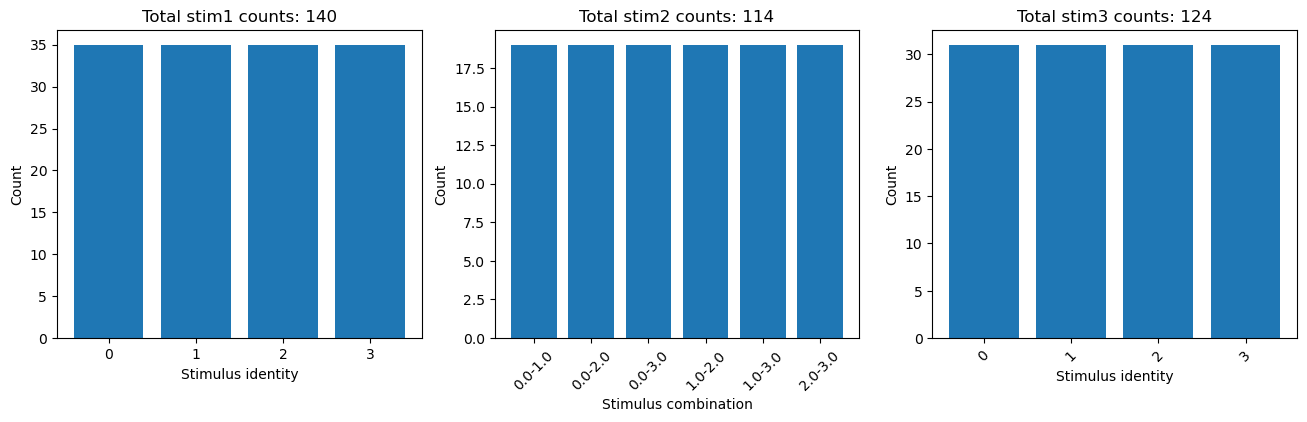

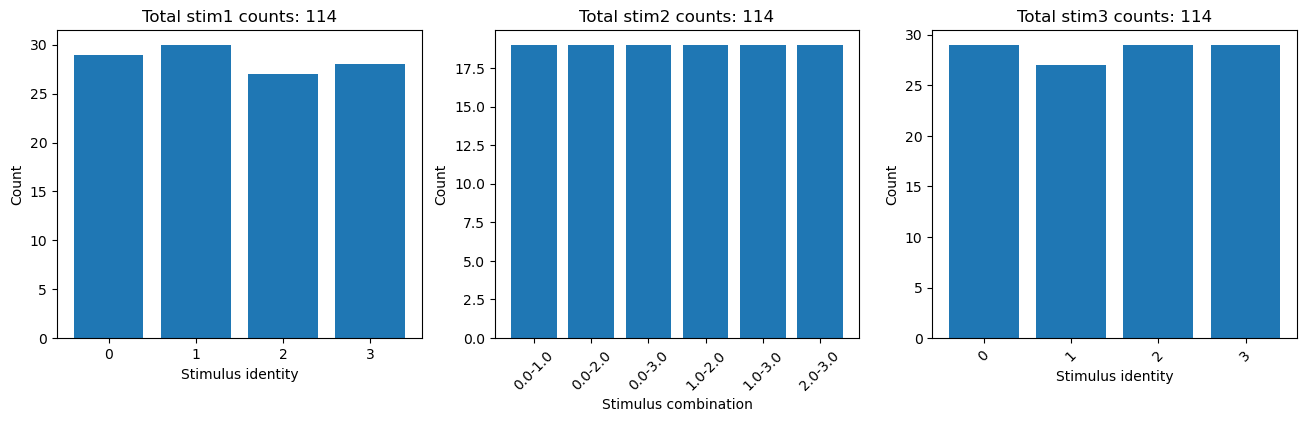

In [59]:
# Sample trials for each load so it's balanced

# For load-1, want trials to include all stimuli
stim1s = trial_labels_corr[load1_idxs, 2]
_, stim1_idxs = np.unique(stim1s, return_inverse=True)
stim1_counts = np.unique(stim1s, return_counts=True)[1] # sample max number of trials per stimulus
max_trials_per_stim1 = np.amin(stim1_counts[stim1_counts > 0])  # minimum count across stimuli
sampled_load1_idxs = []
for stim in np.unique(stim1s):
    stim_idxs = load1_idxs[stim1s == stim]
    sampled_idxs = np.random.choice(stim_idxs, size=max_trials_per_stim1, replace=False)
    sampled_load1_idxs.extend(sampled_idxs)
    
# For load-2, want trials to include all stim combos
stim2s = np.sort(trial_labels_corr[load2_idxs, 2:4], axis=1)  # sort stim combos so that [0,1] and [1,0] are treated the same
_, stim2_idxs = np.unique(stim2s, axis=0, return_inverse=True)
stim2_counts = np.unique(stim2s, axis=0, return_counts=True)[1] # sample max number of trials per stim combo
max_trials_per_stim2 = np.amin(stim2_counts[stim2_counts > 0])  # minimum count across stim combos
sampled_load2_idxs = []
for stim_combo in np.unique(stim2s, axis=0):
    stim_idxs = load2_idxs[np.all(stim2s == stim_combo, axis=1)]
    sampled_idxs = np.random.choice(stim_idxs, size=max_trials_per_stim2, replace=False)
    sampled_load2_idxs.extend(sampled_idxs)
    
# For load-3, want trials to include all left-out stims
stim3s = np.array([np.setdiff1d(np.arange(4), combo)[0] for combo in trial_labels_corr[load3_idxs, 2:5]])
_, stim3_idxs = np.unique(stim3s, return_inverse=True)
stim3_counts = np.unique(stim3s, return_counts=True)[1] # sample max number of trials per left-out stim
max_trials_per_stim3 = np.amin(stim3_counts[stim3_counts > 0])  # minimum count across left-out stims
sampled_load3_idxs = []
for stim in np.unique(stim3s):
    stim_idxs = load3_idxs[np.array(stim3s) == stim]
    sampled_idxs = np.random.choice(stim_idxs, size=max_trials_per_stim3, replace=False)
    sampled_load3_idxs.extend(sampled_idxs)

# test
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
axs[0].hist(trial_labels_corr[sampled_load1_idxs, 2], bins=np.arange(N_STIM+1)-0.5, rwidth=0.8)
axs[0].set_xticks(range(N_STIM))
axs[0].set_xlabel('Stimulus identity')
axs[0].set_ylabel('Count')
axs[0].set_title(f'Total stim1 counts: {len(sampled_load1_idxs)}')

stim2s_sampled = np.sort(trial_labels_corr[sampled_load2_idxs, 2:4], axis=1)
stim2_counts_sampled = np.unique(stim2s_sampled, axis=0, return_counts=True)[1]
axs[1].bar(range(len(stim2_counts_sampled)), stim2_counts_sampled)
axs[1].set_xticks(range(len(stim2_counts_sampled)))
axs[1].set_xticklabels([f'{s[0]}-{s[1]}' for s in np.unique(stim2s_sampled, axis=0)], rotation=45)
axs[1].set_xlabel('Stimulus combination')
axs[1].set_ylabel('Count')
axs[1].set_title(f'Total stim2 counts: {len(sampled_load2_idxs)}')

stim3_lookup = dict(zip(load3_idxs, stim3s))
stim3s_sampled = np.array([stim3_lookup[i] for i in sampled_load3_idxs])
stim3_counts_sampled = np.unique(stim3s_sampled, return_counts=True)[1]
axs[2].bar(range(len(stim3_counts_sampled)), stim3_counts_sampled)
axs[2].set_xticks(range(len(stim3_counts_sampled)))
axs[2].set_xticklabels([f'{s}' for s in np.unique(stim3s_sampled)], rotation=45)
axs[2].set_xlabel('Stimulus identity')
axs[2].set_ylabel('Count')
axs[2].set_title(f'Total stim3 counts: {len(sampled_load3_idxs)}')
plt.show()


# want all of the total_trial counts to be the same, so take the minimum across all three loads
total_trial_counts = [len(sampled_load1_idxs), len(sampled_load2_idxs), len(sampled_load3_idxs)]
min_total_trials = np.amin(total_trial_counts)

# Sample the same number of trials from each load to ensure balanced trial counts, but keep balancing within loads; use seed
sampled_load1_idxs = np.random.choice(sampled_load1_idxs, size=min_total_trials, replace=False)
sampled_load2_idxs = np.random.choice(sampled_load2_idxs, size=min_total_trials, replace=False)
sampled_load3_idxs = np.random.choice(sampled_load3_idxs, size=min_total_trials, replace=False)

# plot the results
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
axs[0].hist(trial_labels_corr[sampled_load1_idxs, 2], bins=np.arange(N_STIM+1)-0.5, rwidth=0.8)
axs[0].set_xticks(range(N_STIM))
axs[0].set_xlabel('Stimulus identity')
axs[0].set_ylabel('Count')
axs[0].set_title(f'Total stim1 counts: {len(sampled_load1_idxs)}')
stim2s_sampled = np.sort(trial_labels_corr[sampled_load2_idxs, 2:4], axis=1)
stim2_counts_sampled = np.unique(stim2s_sampled, axis=0, return_counts=True)[1]
axs[1].bar(range(len(stim2_counts_sampled)), stim2_counts_sampled)
axs[1].set_xticks(range(len(stim2_counts_sampled)))
axs[1].set_xticklabels([f'{s[0]}-{s[1]}' for s in np.unique(stim2s_sampled, axis=0)], rotation=45)
axs[1].set_xlabel('Stimulus combination')
axs[1].set_ylabel('Count')
axs[1].set_title(f'Total stim2 counts: {len(sampled_load2_idxs)}')
stim3s_sampled = stim3s[sampled_load3_idxs]
stim3_counts_sampled = np.unique(stim3s_sampled, return_counts=True)[1]
axs[2].bar(range(len(stim3_counts_sampled)), stim3_counts_sampled)
axs[2].set_xticks(range(len(stim3_counts_sampled)))
axs[2].set_xticklabels([f'{s}' for s in np.unique(stim3s_sampled)], rotation=45)
axs[2].set_xlabel('Stimulus identity')
axs[2].set_ylabel('Count')
axs[2].set_title(f'Total stim3 counts: {len(sampled_load3_idxs)}')
plt.show()

In [ ]:
# Build trial-by trial data
n_trials = min_total_trials
trialR = np.zeros((n_trials, n_neurons, n_loads, n_time))

trialR[:, :, 0, :] = rates_maint[sampled_load1_idxs]
trialR[:, :, 1, :] = rates_maint[sampled_load2_idxs]
trialR[:, :, 2, :] = rates_maint[sampled_load3_idxs]

R = np.mean(trialR, axis=0)  # average across trials
R -= np.mean(R, axis=1, keepdims=True)  # subtract mean across neurons

In [ ]:
dpca = dPCA.dPCA(labels='st',regularizer='auto')
dpca.protect = ['t']

Z = dpca.fit_transform(R,trialR)

print('dPCA components:')
for key, val in Z.items():
    print(f'  {key}: {val.shape}')

You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.0008819763977946266
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please                    set opt_regularizer_flag to True.
dPCA components:
  s: (10, 3, 150)
  t: (10, 3, 15

Explained variance by marginalization:
  s: [0.7505 0.0257 0.     0.     0.     0.     0.     0.     0.     0.    ]
  t: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  st: [0.1626 0.0266 0.016  0.0046 0.0027 0.0017 0.0013 0.0008 0.0007 0.0006]


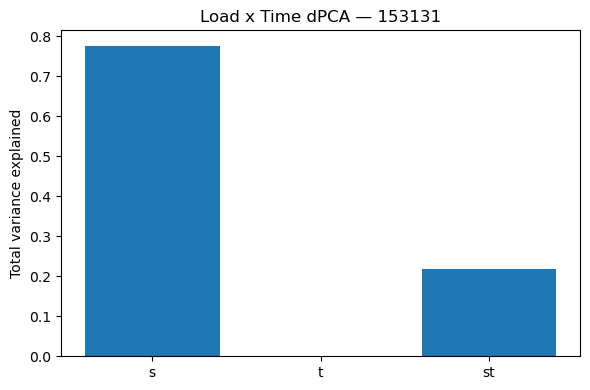

In [ ]:
# Variance explained per marginalization
varexp = dpca.explained_variance_ratio_
print('Explained variance by marginalization:')
for key, val in varexp.items():
    print(f'  {key}: {np.round(val, 4)}')

# Bar chart of total variance per marginalization
fig, ax = plt.subplots(figsize=(6, 4))
keys = list(varexp.keys())
totals = [np.array(varexp[k]).sum() for k in keys]
ax.bar(keys, totals)
ax.set_ylabel('Total variance explained')
ax.set_title(f'Load x Time dPCA — {model_name[-6:]}')
plt.tight_layout()
plt.show()

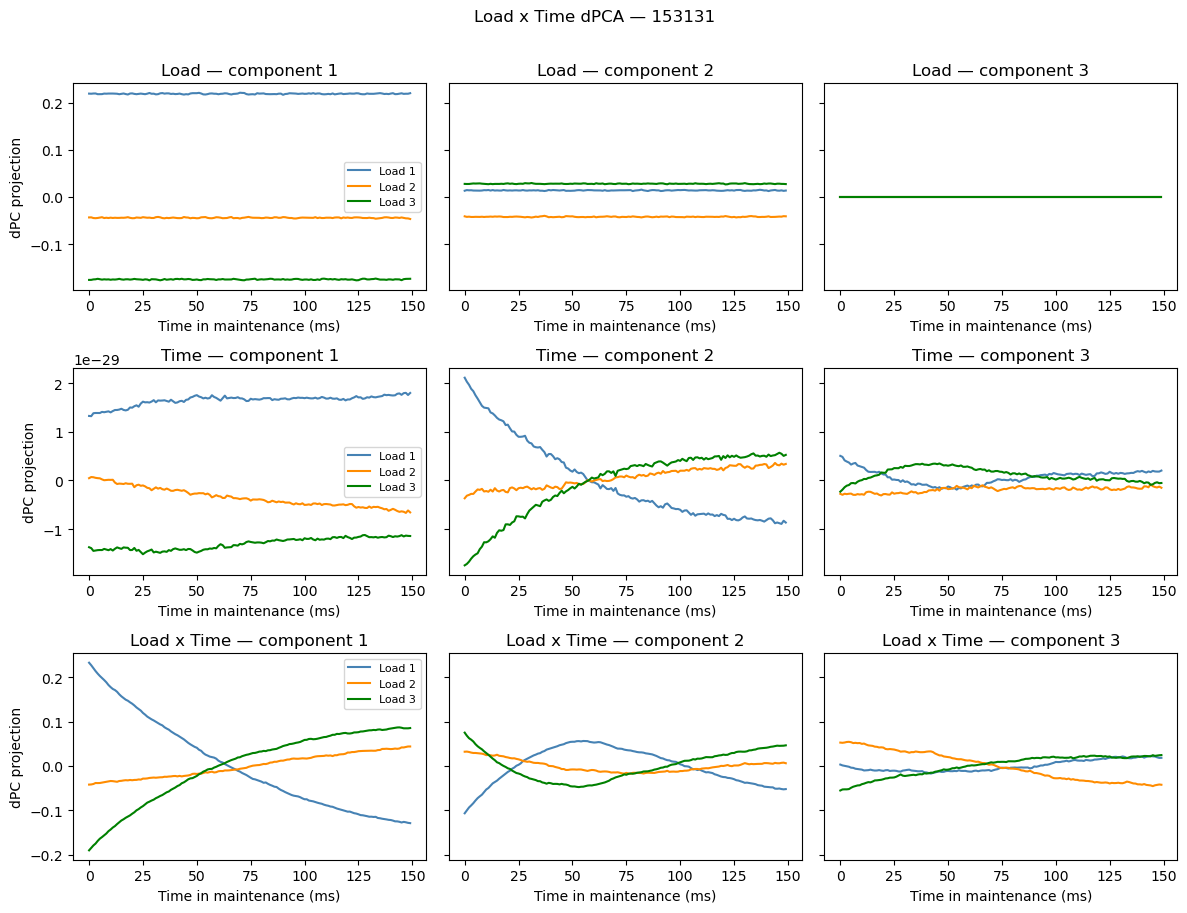

In [ ]:
# Plot top components from each marginalization as time traces
n_components_to_plot = 3
load_colors = ['steelblue', 'darkorange', 'green']
load_labels = ['Load 1', 'Load 2', 'Load 3']
time_axis = np.arange(n_time)

marg_names = {'s': 'Load', 't': 'Time', 'st': 'Load x Time'}

fig, axs = plt.subplots(len(marg_names), n_components_to_plot,
                        figsize=(4 * n_components_to_plot, 3 * len(marg_names)),
                        sharey='row')

for row, (key, name) in enumerate(marg_names.items()):
    comps = Z[key]  # (n_components, n_loads, T)
    for col in range(n_components_to_plot):
        ax = axs[row, col]
        for l_idx, (lc, ll) in enumerate(zip(load_colors, load_labels)):
            ax.plot(time_axis, comps[col, l_idx, :], color=lc, label=ll)
        ax.set_title(f'{name} — component {col+1}')
        ax.set_xlabel('Time in maintenance (ms)')
        if col == 0:
            ax.set_ylabel('dPC projection')
            ax.legend(fontsize=8)

plt.suptitle(f'Load x Time dPCA — {model_name[-6:]}', y=1.01)
plt.tight_layout()
plt.show()

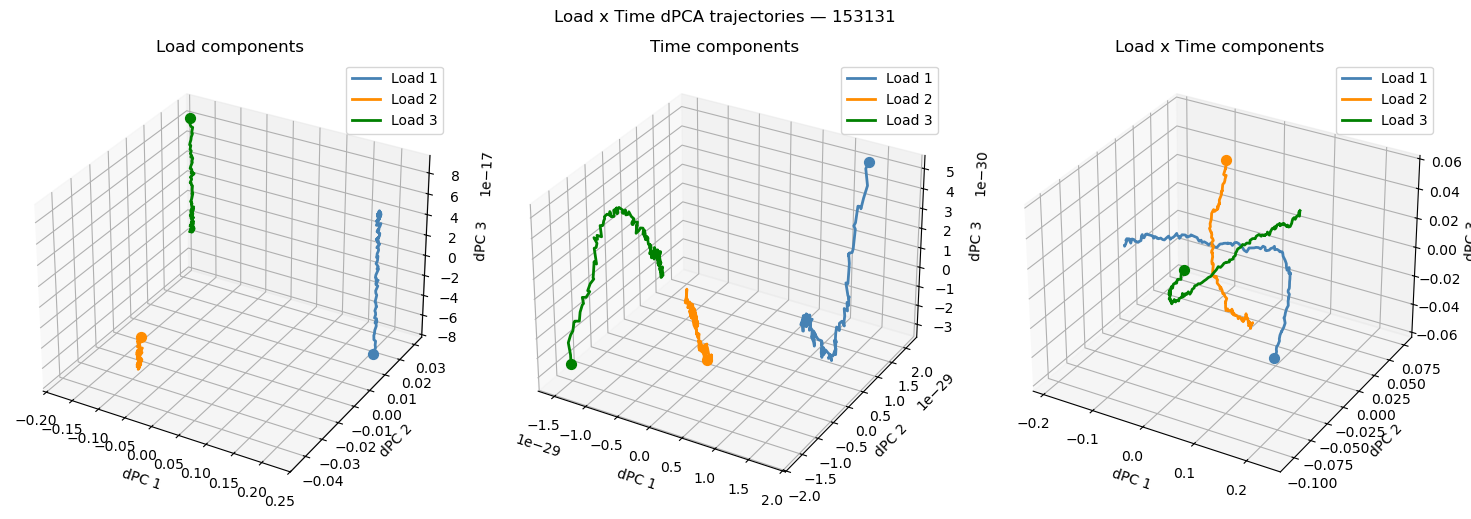

In [ ]:
# 3D trajectory plot of top 3 load-demixed components
# Use first 3 components from each marginalization
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 5))

for col, (key, name) in enumerate(marg_names.items()):
    comps = Z[key]  # (n_components, n_loads, T)
    ax = fig.add_subplot(1, 3, col + 1, projection='3d')
    for l_idx, (lc, ll) in enumerate(zip(load_colors, load_labels)):
        ax.plot(comps[0, l_idx, :], comps[1, l_idx, :], comps[2, l_idx, :],
                color=lc, label=ll, lw=2)
        ax.scatter(comps[0, l_idx, 0], comps[1, l_idx, 0], comps[2, l_idx, 0],
                   color=lc, s=50, zorder=5)  # mark start of trajectory
    ax.set_xlabel('dPC 1')
    ax.set_ylabel('dPC 2')
    ax.set_zlabel('dPC 3')
    ax.set_title(f'{name} components')
    ax.legend()

plt.suptitle(f'Load x Time dPCA trajectories — {model_name[-6:]}', y=1.01)
plt.tight_layout()
plt.show()

# unused

## Analysis 2: Stimulus x Time dPCA (load 1 only)

Within load-1 trials only, build a condition-averaged tensor of shape **(N, n_stim, T)**
and demix into stimulus-selective vs. time-evolving components.

In [ ]:
# Build condition-averaged tensor for load 1: (N, N_STIM, T)
load1_labels = trial_labels_corr[load1_idxs, 2].astype(int)  # stimulus identity for each trial
load1_rates  = rates_maint[load1_idxs]  # trials x neurons x time

R_st = np.zeros((n_neurons, N_STIM, n_time))
for s in range(N_STIM):
    stim_idxs = np.where(load1_labels == s)[0]
    R_st[:, s, :] = load1_rates[stim_idxs].mean(axis=0)

print(f'R_st shape: {R_st.shape}  (neurons x stimuli x time)')
print(f'Trials per stimulus: {[np.sum(load1_labels == s) for s in range(N_STIM)]}')

In [ ]:
dpca_st = dPCA.dPCA(labels='st', regularizer='auto')
dpca_st.protect = ['t']

Z_st = dpca_st.fit_transform(R_st)  # dict: {'s': ..., 't': ..., 'st': ...}

print('dPCA components (stimulus x time):')
for key, val in Z_st.items():
    print(f'  {key}: {val.shape}')

In [ ]:
# Variance explained
varexp_st = dpca_st.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(6, 4))
keys = list(varexp_st.keys())
totals = [varexp_st[k].sum() for k in keys]
ax.bar(keys, totals)
ax.set_ylabel('Total variance explained')
ax.set_title(f'Stimulus x Time dPCA (Load 1) — {model_name[-6:]}')
plt.tight_layout()
plt.show()

In [ ]:
# Time traces of top stimulus-demixed components
stim_colors = ['blue', 'orange', 'green', 'red']
stim_labels = [f'Stim {s}' for s in range(N_STIM)]

marg_names_st = {'s': 'Stimulus', 't': 'Time', 'st': 'Stim x Time'}

fig, axs = plt.subplots(len(marg_names_st), n_components_to_plot,
                        figsize=(4 * n_components_to_plot, 3 * len(marg_names_st)),
                        sharey='row')

for row, (key, name) in enumerate(marg_names_st.items()):
    comps = Z_st[key]  # (n_components, N_STIM, T)
    for col in range(n_components_to_plot):
        ax = axs[row, col]
        for s in range(N_STIM):
            ax.plot(time_axis, comps[col, s, :], color=stim_colors[s], label=stim_labels[s])
        ax.set_title(f'{name} — component {col+1}')
        ax.set_xlabel('Time in maintenance (ms)')
        if col == 0:
            ax.set_ylabel('dPC projection')
            ax.legend(fontsize=8)

plt.suptitle(f'Stimulus x Time dPCA — {model_name[-6:]}', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# 3D trajectory plot of top 3 stimulus-demixed components
fig = plt.figure(figsize=(15, 5))

for col, (key, name) in enumerate(marg_names_st.items()):
    comps = Z_st[key]  # (n_components, N_STIM, T)
    ax = fig.add_subplot(1, 3, col + 1, projection='3d')
    for s in range(N_STIM):
        ax.plot(comps[0, s, :], comps[1, s, :], comps[2, s, :],
                color=stim_colors[s], label=stim_labels[s], lw=2)
        ax.scatter(comps[0, s, 0], comps[1, s, 0], comps[2, s, 0],
                   color=stim_colors[s], s=50, zorder=5)
    ax.set_xlabel('dPC 1')
    ax.set_ylabel('dPC 2')
    ax.set_zlabel('dPC 3')
    ax.set_title(f'{name} components')
    ax.legend()

plt.suptitle(f'Stimulus x Time dPCA (Load 1) — {model_name[-6:]}', y=1.01)
plt.tight_layout()
plt.show()

## Cross-load projection onto stimulus dPCs

Project load-2 and load-3 maintenance activity onto the stimulus-selective dPCs learned from load 1.
This tests whether the same stimulus-coding axes are reused across loads.

In [ ]:
# Decoder matrix for stimulus components: dpca_st.D['s'] has shape (N, n_components)
D_stim = dpca_st.D['s']  # N x n_components
print(f'Stimulus decoder shape: {D_stim.shape}')

# For load 2: average over stim2 (keep stim1 as condition)
load2_rates = rates_maint[load2_idxs]  # trials x neurons x time
load2_stim1 = trial_labels_corr[load2_idxs, 2].astype(int)

load3_rates = rates_maint[load3_idxs]
load3_stim1 = trial_labels_corr[load3_idxs, 2].astype(int)

In [ ]:
# Project single-trial maintenance trajectories onto top 3 stimulus dPCs
# load x: trials x neurons x time -> project onto D_stim[:, :3]
n_proj = 3
D3 = D_stim[:, :n_proj]  # N x 3

def project_trials(rates, decoder):
    """rates: trials x N x T, decoder: N x k -> returns trials x T x k"""
    return np.einsum('tnt,nk->tnk', rates.transpose(0,2,1), decoder).transpose(0,2,1)
    # Actually: (trials x time x N) @ (N x k) -> trials x time x k

def project_trials(rates, decoder):
    """rates: trials x N x T, decoder: N x k -> returns trials x k x T"""
    # rates.T has shape T x N x trials — easier to work trial-by-trial
    n_trials, n_neurons, n_time = rates.shape
    n_k = decoder.shape[1]
    out = np.zeros((n_trials, n_k, n_time))
    for i in range(n_trials):
        out[i] = decoder.T @ rates[i]  # (k x N) @ (N x T) -> k x T
    return out

proj1 = project_trials(rates_maint[load1_idxs], D3)  # trials x 3 x T
proj2 = project_trials(load2_rates, D3)
proj3 = project_trials(load3_rates, D3)
print(f'Projection shapes: {proj1.shape}, {proj2.shape}, {proj3.shape}')

In [ ]:
# Plot trajectories in stimulus-dPC space, colored by stimulus identity
# Load 1: color by stim1; Load 2: color by stim1 (first item); Load 3: color by leftout stim

load1_stims = trial_labels_corr[load1_idxs, 2].astype(int)
load2_labels_noorder = np.sort(trial_labels_corr[load2_idxs, 2:4], axis=1)
_, load2_combo_labels = np.unique(load2_labels_noorder, axis=0, return_inverse=True)
n_load2_combos = len(np.unique(load2_combo_labels))
load2_combo_colors = plt.cm.Set1(np.linspace(0, 1, n_load2_combos + 1))[load2_combo_labels]

label_leftout = [np.setdiff1d(np.arange(4), combo)[0] for combo in trial_labels_corr[load3_idxs, 2:5]]

fig = plt.figure(figsize=(15, 6))

ax = fig.add_subplot(1, 3, 1, projection='3d')
for j in range(len(load1_idxs)):
    ax.plot(proj1[j, 0, :], proj1[j, 1, :], proj1[j, 2, :],
            color=stim_colors[load1_stims[j]], alpha=0.25)
ax.set_title('Load 1 (colored by stim)')
ax.set_xlabel('Stim dPC 1'); ax.set_ylabel('Stim dPC 2'); ax.set_zlabel('Stim dPC 3')
handles = [plt.Line2D([], [], color=stim_colors[s], lw=2, label=f'Stim {s}') for s in range(N_STIM)]
ax.legend(handles=handles, fontsize=8)

ax = fig.add_subplot(1, 3, 2, projection='3d')
for j in range(len(load2_idxs)):
    ax.plot(proj2[j, 0, :], proj2[j, 1, :], proj2[j, 2, :],
            color=load2_combo_colors[j], alpha=0.20)
ax.set_title('Load 2 (projected onto load-1 stim dPCs)')
ax.set_xlabel('Stim dPC 1'); ax.set_ylabel('Stim dPC 2'); ax.set_zlabel('Stim dPC 3')

ax = fig.add_subplot(1, 3, 3, projection='3d')
for j in range(len(load3_idxs)):
    ax.plot(proj3[j, 0, :], proj3[j, 1, :], proj3[j, 2, :],
            color=stim_colors[label_leftout[j]], alpha=0.15)
ax.set_title('Load 3 (projected, colored by leftout stim)')
ax.set_xlabel('Stim dPC 1'); ax.set_ylabel('Stim dPC 2'); ax.set_zlabel('Stim dPC 3')
handles3 = [plt.Line2D([], [], color=stim_colors[s], lw=2, label=f'No stim {s}') for s in range(N_STIM)]
ax.legend(handles=handles3, fontsize=8)

plt.suptitle(f'Cross-load projection onto stimulus dPCs — {model_name[-6:]}', y=1.01)
plt.tight_layout()
plt.show()

## Across models: variance explained by marginalization

In [ ]:
all_varexp_lt = []  # list of dicts, one per model
all_varexp_st = []

for i_model, model_name in enumerate(model_names):
    print(f'Model {i_model+1}/{len(model_names)}: {model_name[-6:]}')
    rates_maint, trial_labels_corr = load_maintenance_rates(model_name)
    n_neurons = rates_maint.shape[1]
    n_time    = rates_maint.shape[2]

    load1_idxs = np.where(trial_labels_corr[:, 0] == 1)[0]
    load2_idxs = np.where(trial_labels_corr[:, 0] == 2)[0]
    load3_idxs = np.where(trial_labels_corr[:, 0] == 3)[0]

    # Load x Time dPCA
    R_lt = np.stack([
        rates_maint[load1_idxs].mean(0),
        rates_maint[load2_idxs].mean(0),
        rates_maint[load3_idxs].mean(0),
    ], axis=1)  # N x 3 x T

    dpca_lt = dPCA.dPCA(labels='lt', regularizer='auto')
    dpca_lt.protect = ['t']
    dpca_lt.fit(R_lt)
    all_varexp_lt.append(dpca_lt.explained_variance_ratio_)

    # Stimulus x Time dPCA (load 1 only)
    load1_labels = trial_labels_corr[load1_idxs, 2].astype(int)
    load1_rates  = rates_maint[load1_idxs]
    R_st = np.zeros((n_neurons, N_STIM, n_time))
    for s in range(N_STIM):
        stim_idxs = np.where(load1_labels == s)[0]
        R_st[:, s, :] = load1_rates[stim_idxs].mean(0)

    dpca_st = dPCA.dPCA(labels='st', regularizer='auto')
    dpca_st.protect = ['t']
    dpca_st.fit(R_st)
    all_varexp_st.append(dpca_st.explained_variance_ratio_)

In [ ]:
# Summary plot: total variance per marginalization, across models
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

lt_keys = list(all_varexp_lt[0].keys())
lt_totals = np.array([[d[k].sum() for k in lt_keys] for d in all_varexp_lt])  # models x keys

st_keys = list(all_varexp_st[0].keys())
st_totals = np.array([[d[k].sum() for k in st_keys] for d in all_varexp_st])

x = np.arange(len(lt_keys))
for i_model in range(len(model_names)):
    axs[0].plot(x, lt_totals[i_model], 'o-', alpha=0.6, label=model_names[i_model][-6:])
axs[0].set_xticks(x); axs[0].set_xticklabels(lt_keys)
axs[0].set_ylabel('Total variance explained')
axs[0].set_title('Load x Time dPCA')
axs[0].axhline(lt_totals.mean(0).mean(), color='k', linestyle='--', alpha=0.4, label='mean')

x2 = np.arange(len(st_keys))
for i_model in range(len(model_names)):
    axs[1].plot(x2, st_totals[i_model], 'o-', alpha=0.6, label=model_names[i_model][-6:])
axs[1].set_xticks(x2); axs[1].set_xticklabels(st_keys)
axs[1].set_ylabel('Total variance explained')
axs[1].set_title('Stimulus x Time dPCA (Load 1)')

plt.suptitle('Variance explained by marginalization — all models')
plt.tight_layout()
plt.show()

print('\nLoad x Time — mean variance per marginalization:')
for k, v in zip(lt_keys, lt_totals.mean(0)):
    print(f'  {k}: {v:.4f}')

print('\nStimulus x Time (Load 1) — mean variance per marginalization:')
for k, v in zip(st_keys, st_totals.mean(0)):
    print(f'  {k}: {v:.4f}')